# Seasonal Agriculture Performance Analysis

### Major Project

This project is an analysis of agriculture performance in various seasons.
The performance includes yield, profit, rainfall, water consumption, crop performance,
and other agricultural factors.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## Understanding the Dataset

First, we check the size and structure of the dataset.


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.info()

Number of rows: 4000
Number of columns: 28
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitro

In [7]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [8]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


## Data Cleaning

Missing values are checked before performing the main analysis.

In [9]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [10]:
#fill missing values
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(
    df['Rainfall_mm'].mean()
)

df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df['Soil_Moisture_pct'].mean()
)

df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df['Yield_Tonnes_Ha'].mean()
)

In [11]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


All missing values have been handled, so the dataset is ready for further analysis.

## Check Duplicate

In [12]:
df.duplicated().sum()

np.int64(0)

## Basic Statistics

The following summary shows basic statistical information such as
average, minimum and maximum values.

In [13]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.185807,3.81818,11.960834,1.121186,0.641461,6.678828,31.216452,17.015074,27.742681,...,0.101747,13.307831,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,585.950000,26.90000,63.000000,7.300000,6.690000,26.500000,120.100000,57.500000,105.100000,...,0.830000,1.750000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.880000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


## Seasonal Analysis

The dataset contains agricultural records from different seasons.
First, we check how many records are available for each season.

In [14]:
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [15]:
# Average yield by season
season_yield = df.groupby('Season', as_index=False)[
    'Yield_Tonnes_Ha'
].mean()

season_yield

,Season,Yield_Tonnes_Ha
0,Kharif,5.642504
1,Rabi,5.082835
2,Zaid,4.671032


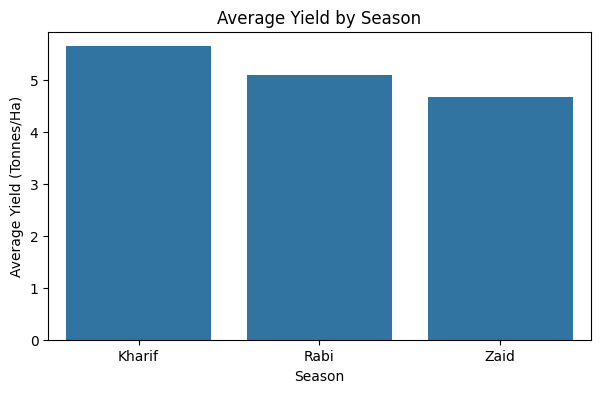

In [16]:
#Yeild Graph
plt.figure(figsize=(7,4))

sns.barplot(
    data=season_yield,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.show()

### Yield Variation

A boxplot helps us see how yield varies within each season and also helps
identify unusually high or low values.

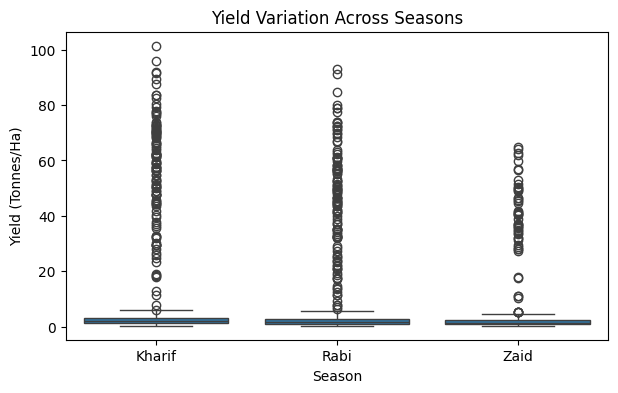

In [17]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Variation Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [18]:
#Average profit by season
season_profit = df.groupby('Season', as_index=False)[
    'Profit_INR'
].mean()

season_profit

,Season,Profit_INR
0,Kharif,178914.647555
1,Rabi,87689.470191
2,Zaid,-24804.824916


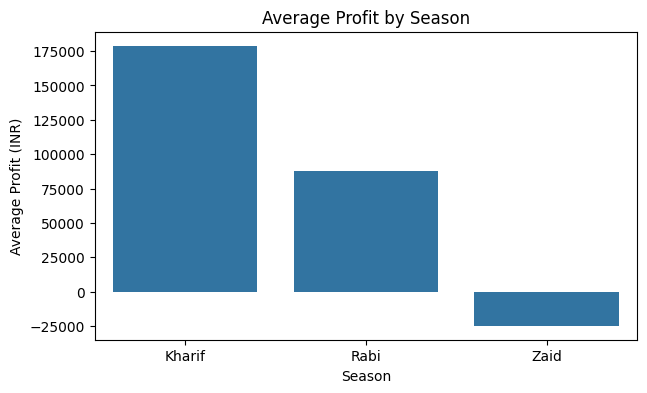

In [19]:
#Profit Graph
plt.figure(figsize=(7,4))

sns.barplot(
    data=season_profit,
    x='Season',
    y='Profit_INR'
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.show()

## Water Usage Across Seasons

Water is an important resource in agriculture. Here we compare the
average water used in different seasons.

In [20]:
season_water = df.groupby('Season', as_index=False)[
    'Water_Used_m3'
].mean()

season_water

,Season,Water_Used_m3
0,Kharif,6102.201237
1,Rabi,5846.987093
2,Zaid,6419.893939


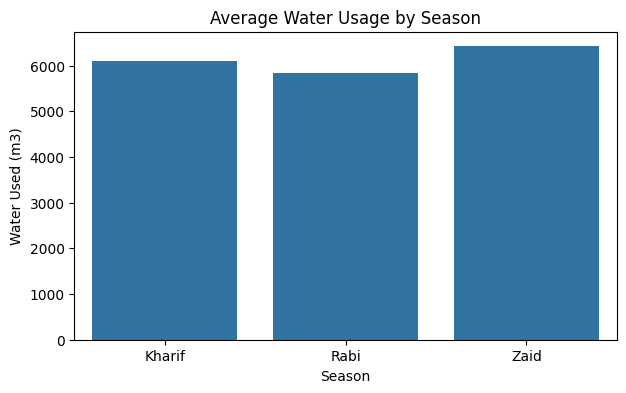

In [21]:
#Water Usage graph
plt.figure(figsize=(7,4))

sns.barplot(
    data=season_water,
    x='Season',
    y='Water_Used_m3'
)

plt.title('Average Water Usage by Season')
plt.xlabel('Season')
plt.ylabel('Water Used (m3)')
plt.show()

In [22]:
#Water effiecency
water_efficiency = df.groupby('Season', as_index=False)[
    'Water_Efficiency_t_per_1000m3'
].mean()

water_efficiency

,Season,Water_Efficiency_t_per_1000m3
0,Kharif,5.891834
1,Rabi,5.186122
2,Zaid,4.413239


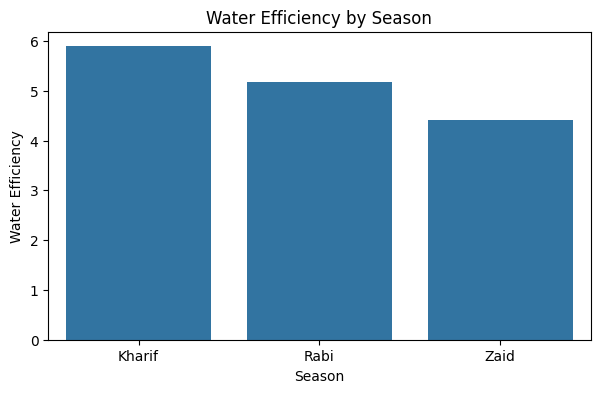

In [23]:
#Water effiecency graph
plt.figure(figsize=(7,4))

sns.barplot(
    data=water_efficiency,
    x='Season',
    y='Water_Efficiency_t_per_1000m3'
)

plt.title('Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Water Efficiency')
plt.show()

## Crop-wise Analysis

Different crops may have different levels of yield and profit.

In [24]:
df['Crop'].value_counts()

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


In [25]:
#Average Yield by Crop
crop_yield = df.groupby('Crop', as_index=False)[
    'Yield_Tonnes_Ha'
].mean().sort_values(
    'Yield_Tonnes_Ha',
    ascending=False
)

crop_yield


,Crop,Yield_Tonnes_Ha
6,Sugarcane,46.665512
3,Maize,2.735667
5,Rice,2.472239
7,Wheat,2.119513
0,Chilli,1.585614
2,Groundnut,1.364535
1,Cotton,1.257583
4,Pulses,0.935748


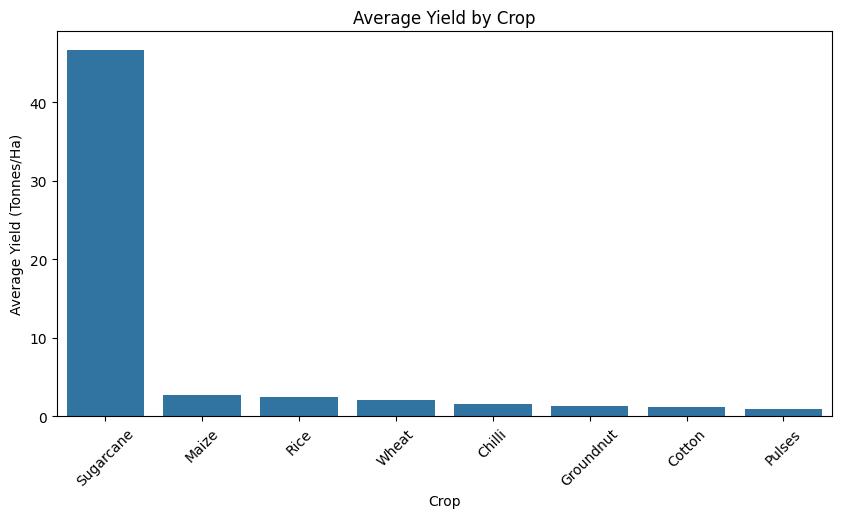

In [26]:
#Crop yeild graph
plt.figure(figsize=(10,5))

sns.barplot(
    data=crop_yield,
    x='Crop',
    y='Yield_Tonnes_Ha'
)

plt.title('Average Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

In [27]:
#Average profit by graph
crop_profit = df.groupby('Crop', as_index=False)[
    'Profit_INR'
].mean().sort_values(
    'Profit_INR',
    ascending=False
)

crop_profit

,Crop,Profit_INR
6,Sugarcane,817187.986885
0,Chilli,750878.342233
1,Cotton,124546.915354
2,Groundnut,44858.120283
4,Pulses,-4238.052419
3,Maize,-83978.326679
5,Rice,-102213.504348
7,Wheat,-123398.337134


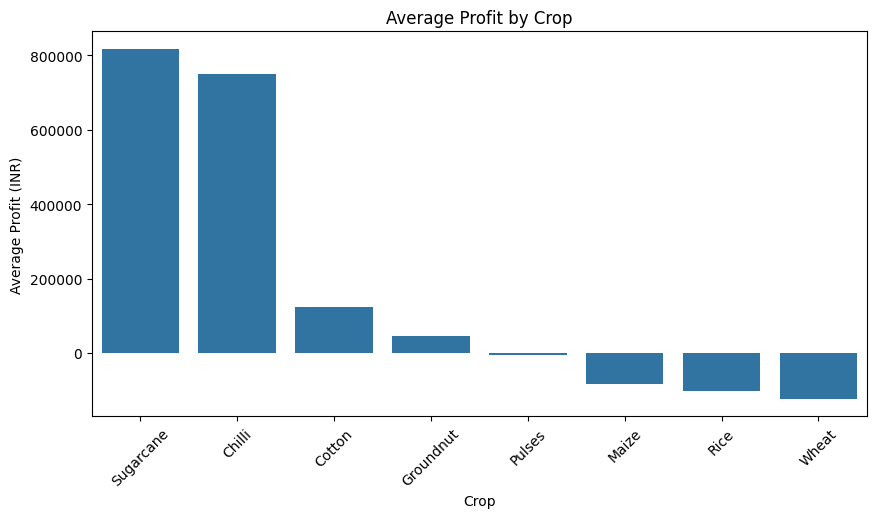

In [28]:
#Crop profit graph
plt.figure(figsize=(10,5))

sns.barplot(
    data=crop_profit,
    x='Crop',
    y='Profit_INR'
)

plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.show()

## Irrigation Analysis

Different irrigation methods are compared to understand their effect
on agricultural performance.

In [29]:
df['Irrigation_Method'].value_counts()

,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


In [30]:
irrigation_yield = df.groupby(
    'Irrigation_Method',
    as_index=False
)['Yield_Tonnes_Ha'].mean().sort_values(
    'Yield_Tonnes_Ha',
    ascending=False
)

irrigation_yield

,Irrigation_Method,Yield_Tonnes_Ha
0,Drip,6.608858
3,Sprinkler,5.189487
1,Flood,4.901709
2,Rainfed,4.615708


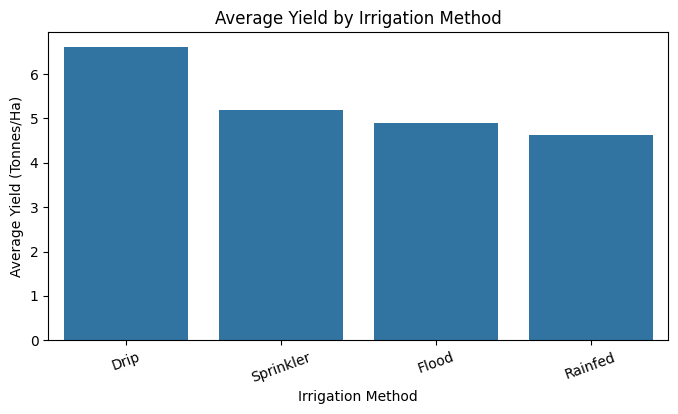

In [31]:
#Irrigation yield graph
plt.figure(figsize=(8,4))

sns.barplot(
    data=irrigation_yield,
    x='Irrigation_Method',
    y='Yield_Tonnes_Ha'
)

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=20)
plt.show()

In [32]:
#Irrigation and water efficiency
irrigation_efficiency = df.groupby(
    'Irrigation_Method',
    as_index=False
)['Water_Efficiency_t_per_1000m3'].mean().sort_values(
    'Water_Efficiency_t_per_1000m3',
    ascending=False
)

irrigation_efficiency

,Irrigation_Method,Water_Efficiency_t_per_1000m3
2,Rainfed,7.563784
0,Drip,6.267129
3,Sprinkler,4.669805
1,Flood,3.438853


## Environmental Conditions and Yield

Rainfall, temperature and soil moisture may have an effect on
agricultural yield. Scatter plots are used to observe these relationships.

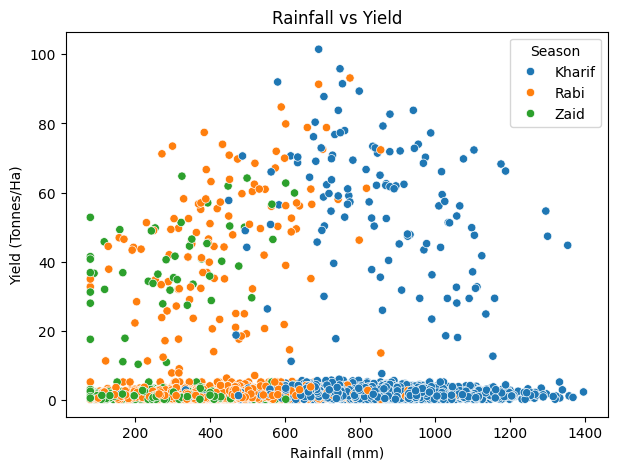

In [33]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall vs Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

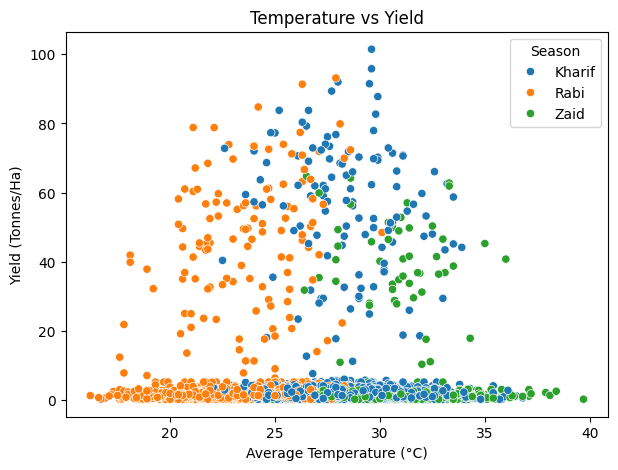

In [34]:
#Temprature and yield
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Temperature vs Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

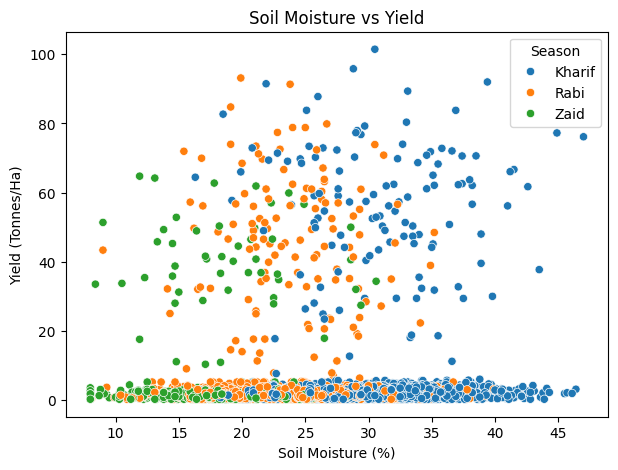

In [35]:
#Soil moisture and yield
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='Soil_Moisture_pct',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Soil Moisture vs Yield')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

## Correlation Analysis

Correlation helps us understand the relationship between numerical
variables and yield.

In [36]:
corr = df[[
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Water_Used_m3',
    'Profit_INR'
]].corr()

corr.round(2)

,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Fertilizer_kg_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Water_Used_m3,Profit_INR
Rainfall_mm,1.00,0.20,0.51,0.02,-0.02,0.03,0.00,0.11
Avg_Temperature_C,0.20,1.00,0.08,0.02,-0.03,0.01,0.02,0.01
Soil_Moisture_pct,0.51,0.08,1.00,0.01,-0.02,0.01,0.00,0.09
Fertilizer_kg_ha,0.02,0.02,0.01,1.00,0.02,0.00,0.00,-0.07
Seed_Quality_Score,-0.02,-0.03,-0.02,0.02,1.00,-0.01,0.02,0.01
Yield_Tonnes_Ha,0.03,0.01,0.01,0.00,-0.01,1.00,0.39,0.49
Water_Used_m3,0.00,0.02,0.00,0.00,0.02,0.39,1.00,0.19
Profit_INR,0.11,0.01,0.09,-0.07,0.01,0.49,0.19,1.00


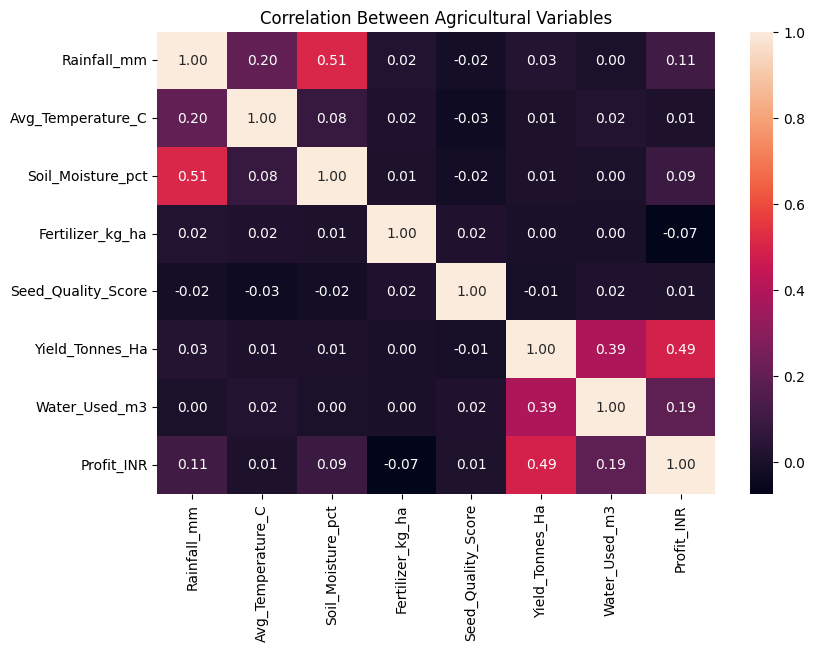

In [37]:
#Correlation Heatmap
plt.figure(figsize=(9,6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Between Agricultural Variables')
plt.show()

In [38]:
#Variable related to  Yield
yield_corr = corr['Yield_Tonnes_Ha'].sort_values(
    ascending=False
)

yield_corr.round(2)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.00
Profit_INR,0.49
Water_Used_m3,0.39
Rainfall_mm,0.03
Soil_Moisture_pct,0.01
Avg_Temperature_C,0.01
Fertilizer_kg_ha,0.00
Seed_Quality_Score,-0.01


## Economic Performance

Revenue, cost and profit are compared across seasons to understand
the economic side of agricultural performance.

In [39]:
economic = df.groupby('Season')[[
    'Revenue_INR',
    'Total_Cost_INR',
    'Profit_INR'
]].mean()

economic.round(2)

,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.06,531804.41,178914.65
Rabi,601526.05,513836.58,87689.47
Zaid,519171.90,543976.73,-24804.82


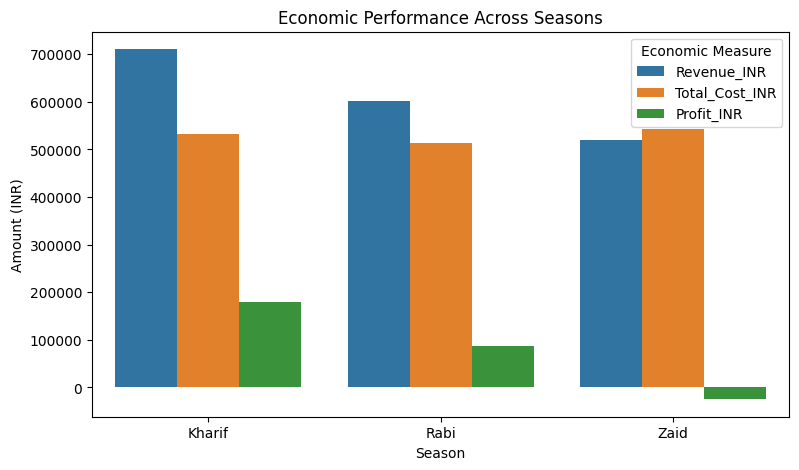

In [40]:
#Economic Graph
economic_plot = economic.reset_index().melt(
    id_vars='Season',
    var_name='Economic Measure',
    value_name='Amount'
)

plt.figure(figsize=(9,5))

sns.barplot(
    data=economic_plot,
    x='Season',
    y='Amount',
    hue='Economic Measure'
)

plt.title('Economic Performance Across Seasons')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.show()

## Identifying Unusual Profit Values

The highest and lowest profit values are checked to find farms with
unusual economic performance.

In [41]:
print("Highest Profit:", df['Profit_INR'].max())
print("Lowest Profit:", df['Profit_INR'].min())

Highest Profit: 4345421
Lowest Profit: -1019223


In [42]:
#Highest profit farms
df[[
    'Farm_ID',
    'State',
    'Crop',
    'Season',
    'Profit_INR'
]].sort_values(
    'Profit_INR',
    ascending=False
).head(10)

,Farm_ID,State,Crop,Season,Profit_INR
2236,SF12237,Punjab,Chilli,Kharif,4345421
626,SF10627,Maharashtra,Chilli,Kharif,4021850
3425,SF13426,Madhya Pradesh,Sugarcane,Kharif,3740099
1690,SF11691,Karnataka,Chilli,Kharif,3738329
247,SF10248,Maharashtra,Chilli,Kharif,3542204
357,SF10358,Punjab,Sugarcane,Rabi,3378879
3423,SF13424,Andhra Pradesh,Sugarcane,Kharif,3330582
1930,SF11931,Tamil Nadu,Sugarcane,Kharif,3232970
3983,SF13984,Gujarat,Chilli,Kharif,3211345
263,SF10264,Maharashtra,Chilli,Rabi,3159447


In [43]:
#Lowest Profit Farms
df[[
    'Farm_ID',
    'State',
    'Crop',
    'Season',
    'Profit_INR'
]].sort_values(
    'Profit_INR'
).head(10)

,Farm_ID,State,Crop,Season,Profit_INR
780,SF10781,Andhra Pradesh,Groundnut,Rabi,-1019223
2210,SF12211,Andhra Pradesh,Wheat,Rabi,-995195
3625,SF13626,Punjab,Maize,Rabi,-981050
2182,SF12183,Andhra Pradesh,Rice,Kharif,-976860
104,SF10105,Gujarat,Wheat,Zaid,-965197
3394,SF13395,Gujarat,Wheat,Kharif,-963396
2730,SF12731,Madhya Pradesh,Rice,Rabi,-906082
1311,SF11312,Punjab,Rice,Zaid,-902740
585,SF10586,Telangana,Cotton,Zaid,-895730
3090,SF13091,Karnataka,Maize,Kharif,-890641


## Crop Performance Across Seasons

A crop may perform differently in different seasons. Therefore,
average yield is compared using both crop and season.

In [44]:
season_crop = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

season_crop.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.75,1.51,1.31
Cotton,1.39,1.23,1.00
Groundnut,1.50,1.31,1.04
Maize,2.97,2.65,2.33
Pulses,1.04,0.89,0.73
Rice,2.73,2.39,1.90
Sugarcane,53.46,43.34,38.42
Wheat,2.27,2.07,1.75


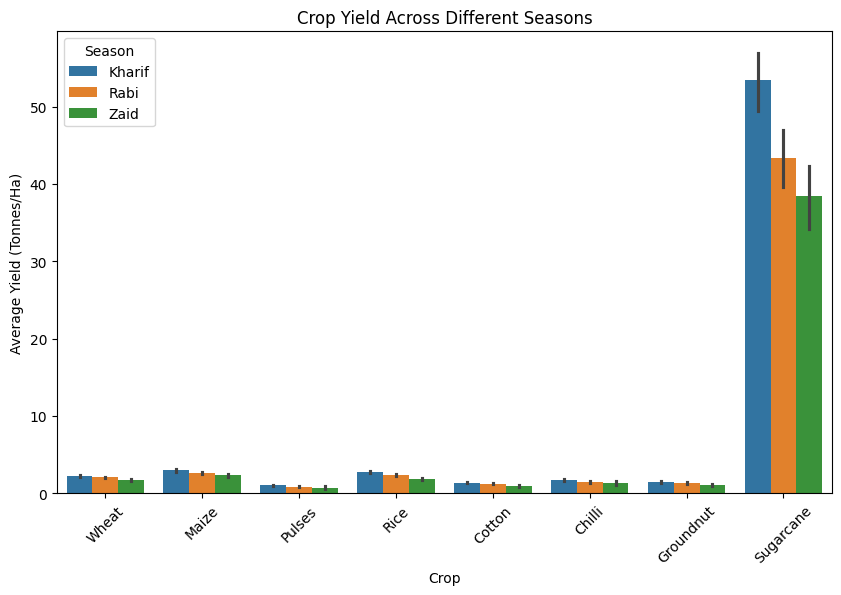

In [45]:
#Season Crop Graph
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Crop',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Crop Yield Across Different Seasons')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

## Yield Distribution

A histogram is used to understand how the yield values are distributed
across the dataset.

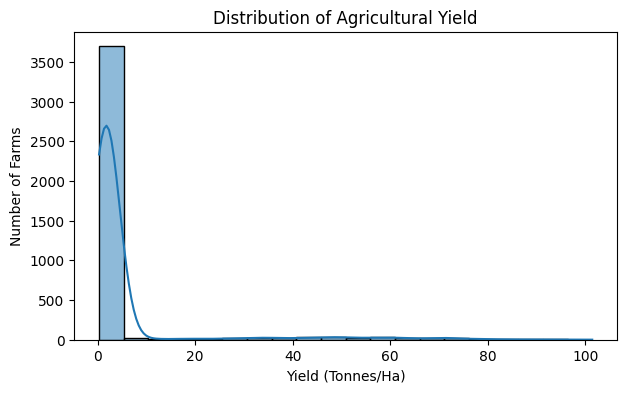

In [46]:
plt.figure(figsize=(7,4))

sns.histplot(
    data=df,
    x='Yield_Tonnes_Ha',
    bins=20,
    kde=True
)

plt.title('Distribution of Agricultural Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Number of Farms')
plt.show()

# Significant Observation

* Kharif season has the highest mean yield of about 5.64 tonnes/ha whereas Zaid season has the lowest mean yield of about 4.67 tonnes/ha.

* Kharif season has the highest mean profit whereas Zaid season has the negative mean profit of about ₹24,805.

* Zaid season requires the highest amount of mean water use and has the lowest water efficiency out of the three seasons.

* Sugarcane is the crop having the highest mean yield and mean profit out of all the crops present in the dataset.

* The method of drip irrigation has the highest mean yield whereas rainfed farming has the highest water efficiency.

* Yield shows the moderate positive correlation with profit and water use whereas the correlations of rainfall, temperature, soil moisture, fertilizers, and seed quality with yield are very weak.

* The mean yield of each of the crops is highest in Kharif season and lowest in Zaid season.

* There are some farms which earn very high profits while there are others which are earning losses.

## Conclusion

From the analysis, it is evident that agriculture performance is different depending on the seasons considered. Kharif had the highest yield and profitability averages while Zaid had the lowest yield average, water use efficiency and negative average profitability.

On crop-based analysis, it was evident that Sugarcane had the highest yield and profitability averages. On the analysis of the effect of irrigation systems, it was evident that Drip irrigation had the highest yield average.

Correlation analysis revealed a strong positive correlation between yield and profitability and water used while weak linear correlations were revealed for all the environmental variables against yield in the data set under analysis. Crop and seasons comparison also showed that yield average was highest in Kharif and lowest in Zaid for the crops under analysis.


# Recommendations

1. Seasonal factors must be kept in mind while making decisions about crops since Kharif performed better in terms of yield and profitability than Rabi and Zaid.

2. The usage of water must be checked carefully during Zaid season since it uses more water and is also less water efficient compared to others.

3. Drip irrigation must be given due consideration since it provided the best average yield among all the other irrigation systems used in the dataset.

4. Crops that are selected must have considerations of yield and profit in mind since sugarcane has the highest yield and profitability.

5. Cases where the farms have high or low profits must be investigated.

6. Season and crop wise historical data must be considered for future agricultural decision-making.